<a href="https://colab.research.google.com/github/Bittah-C0ding/adrian-data-science-portfolio/blob/main/decisiontrees(AH).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load the bank data
import pandas as pd
bank = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Target: turn yes/no into 1/0
bank['y'] = bank['y'].map({'yes': 1, 'no': 0})

# pdays 999 means "never contacted before" -> make a flag, then set it to -1
bank['was_contacted_before'] = (bank['pdays'] != 999).astype(int)
bank['pdays'] = bank['pdays'].replace(999, -1)

# Features = every column except y. get_dummies turns text columns into 0/1 columns
X = pd.get_dummies(bank.drop(columns='y'), drop_first=True)
y = bank['y']

# Split: 80% train, 20% test (stratify keeps the yes/no ratio the same)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Pruned tree (max_depth and min_samples_leaf stop overfitting)
clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',  # only ~11% say yes, so balance the classes
    random_state=42)

# Train it
clf.fit(X_train, y_train)

# Test it (accuracy alone is misleading here, so print the full report)
pred = clf.predict(X_test)
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[5745  827]
 [ 315  527]]
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      6572
           1       0.39      0.63      0.48       842

    accuracy                           0.85      7414
   macro avg       0.67      0.75      0.69      7414
weighted avg       0.88      0.85      0.86      7414



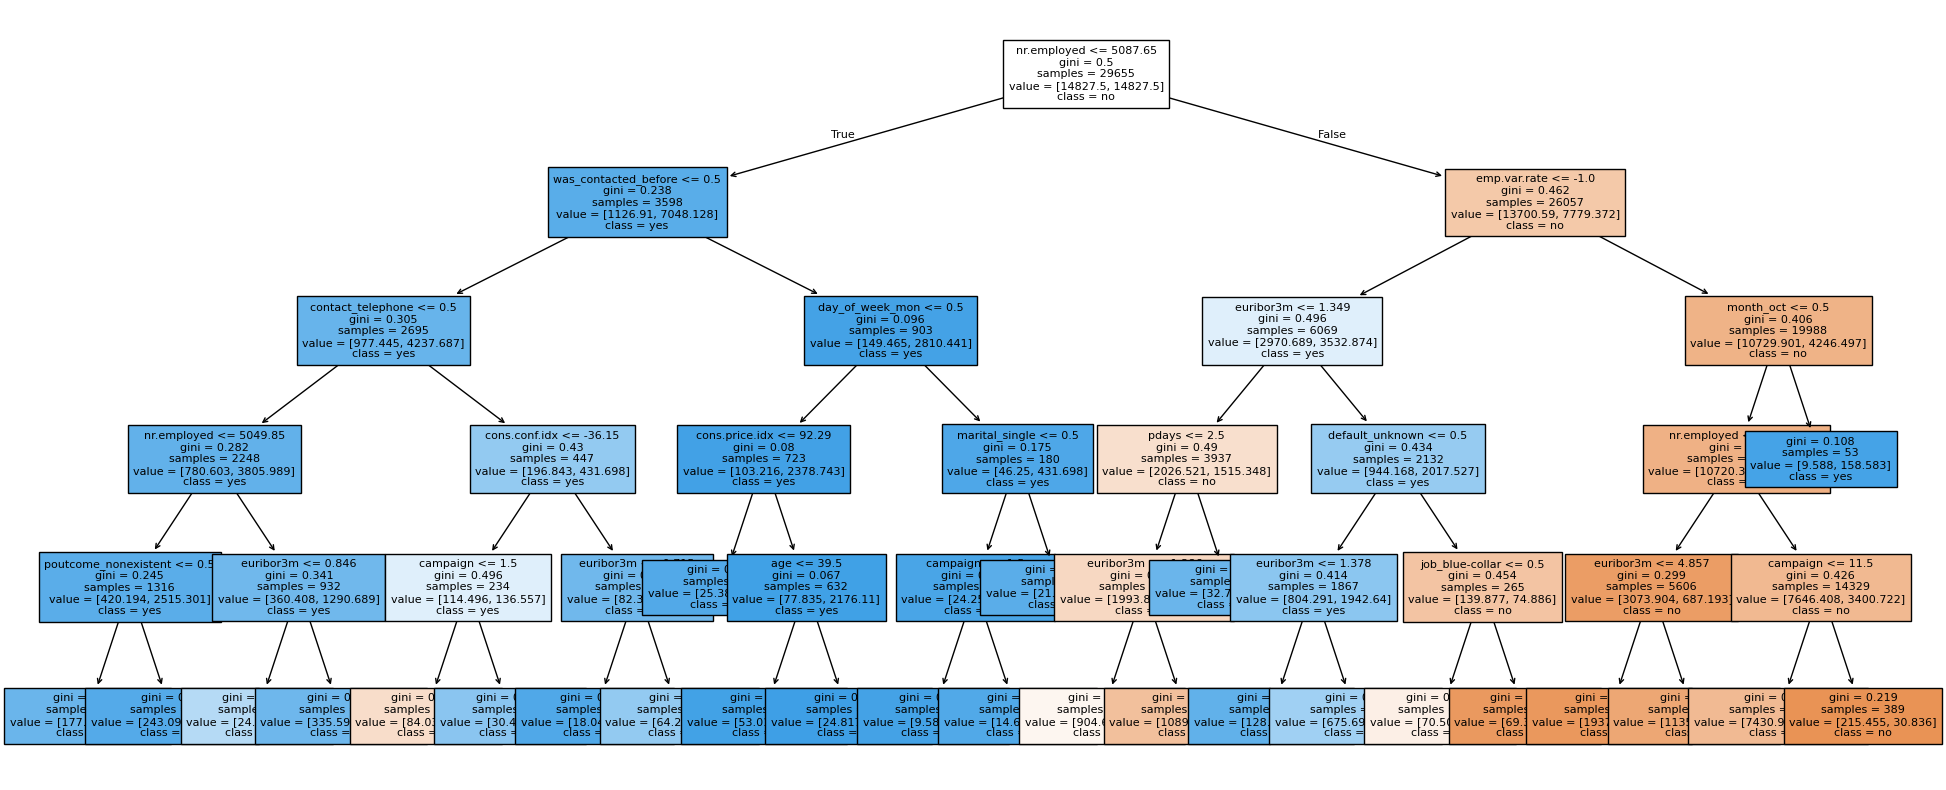

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree

# Smaller tree now, so it's readable
fig, ax = plt.subplots(figsize=(24, 10))
tree.plot_tree(clf, fontsize=8, feature_names=X.columns,
               class_names=['no', 'yes'], filled=True)
plt.show()

In [ ]:
import pickle

# Which features matter most?
importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(10))

# Save the model with protocol 5
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(clf, f, protocol=5)

nr.employed             0.698548
emp.var.rate            0.139588
euribor3m               0.068518
month_oct               0.033765
was_contacted_before    0.016162
default_unknown         0.011688
pdays                   0.011026
campaign                0.006253
contact_telephone       0.005159
cons.conf.idx           0.003896
dtype: float64


In [ ]:
# Holdout file and apply the SAME steps as training
test = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test.csv')
test = test.drop(columns='y', errors='ignore')  # in case a y column exists
test['was_contacted_before'] = (test['pdays'] != 999).astype(int)
test['pdays'] = test['pdays'].replace(999, -1)
test = pd.get_dummies(test, drop_first=True)

# Make columns match training exactly (fills any missing ones with 0)
test = test.reindex(columns=X.columns, fill_value=0)

# Predict and save. Header must be "predictions"
out = pd.DataFrame(clf.predict(test), columns=['predictions'])
out.to_csv('predictions.csv', index=False)
print(len(out))  # should print 4119

4119
